## 1) Загрузка данныз из файла с вопросами

In [9]:
import pandas as pd
import json

file_path = 'benchmark_dataset.jsonl'

data = []
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

print(f"Всего записей до чистки: {len(df)}")
df.head()

Всего записей до чистки: 106


,exam_id,page_id,path_to_page,question_id,question_type,question_text,answer_type,max_score,canonical_answer,status,error_comment
0,exam_1,2,exam_data/pages/exam_1/page_2.png,1,text,What is the pKa of a sp hybridized carbon atom...,single_choice,1.0,A,ok,None
1,exam_1,2,exam_data/pages/exam_1/page_2.png,2,text,A) choose the letter of the molecule with the ...,multiple_choice,2.0,A;D,ok,None
2,exam_1,2,exam_data/pages/exam_1/page_2.png,3,text,Rank the following substituents in order of pr...,ordering,2.0,4;2;3;1,ok,None
3,exam_1,2,exam_data/pages/exam_1/page_2.png,4,text,If a chiral molecule has an absolute configura...,single_choice,1.0,D,ok,None
4,exam_1,3,exam_data/pages/exam_1/page_3.png,5,multimodal,A) Enter the pKa value for each acid in the bo...,text,6.0,box_1=8-11; box_2=15.7; box_3=10-11; box_4=4-5,ok,None


## 2) Анализ результатов парсинга

In [ ]:
status_counts = df['status'].value_counts()
print("Распределение статусов:")
print(status_counts)

# 1. Оставляем только успешные результаты
df_clean = df[df['status'] == 'ok'].copy()

# 2. Заполнение баллов: если max_score равен 0, None или NaN — ставим 1.0
df_clean['max_score'] = pd.to_numeric(df_clean['max_score'], errors='coerce')
zero_scores_count = ((df_clean['max_score'] == 0) | (
    df_clean['max_score'].isna())).sum()

# Заполняем 1.0
df_clean.loc[(df_clean['max_score'] == 0) | (
    df_clean['max_score'].isna()), 'max_score'] = 1.0

print(f"Чистка завершена:")
print(f"- Удалено unreadable: {len(df) - len(df_clean)}")
print(f"- Заполнено баллов (с 0 на 1.0): {zero_scores_count}")

df_clean = df_clean.drop(columns=['status', 'error_comment'])

df_clean.head()

Распределение статусов:
status
ok            75
unreadable    31
Name: count, dtype: int64
Чистка завершена:
- Удалено unreadable/error: 31
- Заполнено баллов (с 0 на 1.0): 7


,exam_id,page_id,path_to_page,question_id,question_type,question_text,answer_type,max_score,canonical_answer
0,exam_1,2,exam_data/pages/exam_1/page_2.png,1,text,What is the pKa of a sp hybridized carbon atom...,single_choice,1.0,A
1,exam_1,2,exam_data/pages/exam_1/page_2.png,2,text,A) choose the letter of the molecule with the ...,multiple_choice,2.0,A;D
2,exam_1,2,exam_data/pages/exam_1/page_2.png,3,text,Rank the following substituents in order of pr...,ordering,2.0,4;2;3;1
3,exam_1,2,exam_data/pages/exam_1/page_2.png,4,text,If a chiral molecule has an absolute configura...,single_choice,1.0,D
4,exam_1,3,exam_data/pages/exam_1/page_3.png,5,multimodal,A) Enter the pKa value for each acid in the bo...,text,6.0,box_1=8-11; box_2=15.7; box_3=10-11; box_4=4-5


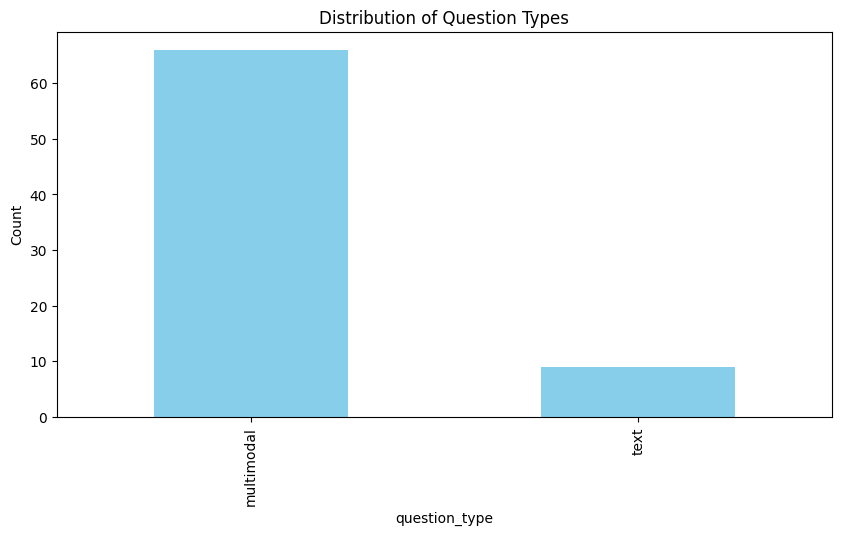

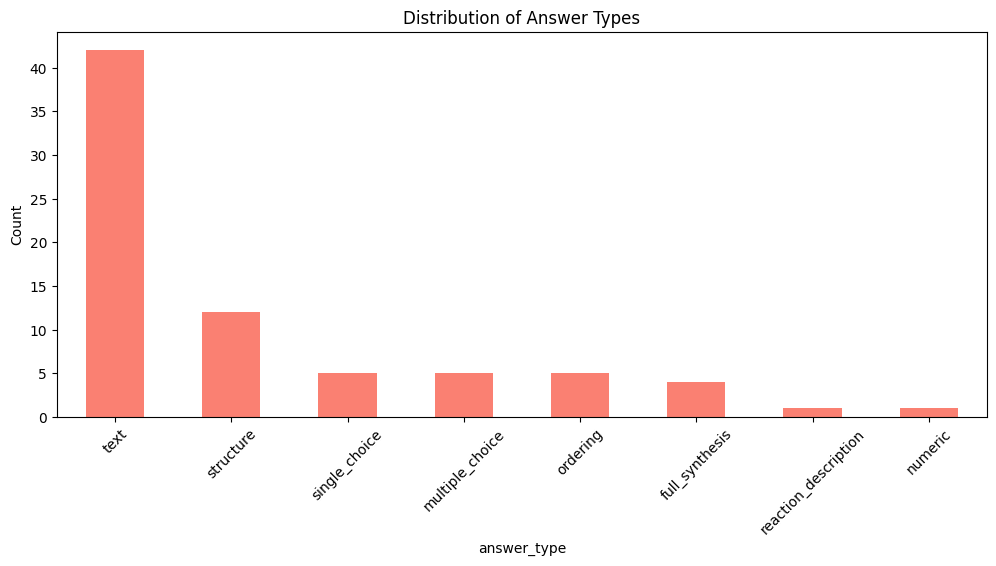

Средний балл за вопрос: 7.04


In [6]:
import matplotlib.pyplot as plt

# 1. Распределение по типам вопросов
plt.figure(figsize=(10, 5))
df_clean['question_type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Question Types')
plt.ylabel('Count')
plt.show()

# 2. Распределение по типам ответов
plt.figure(figsize=(12, 5))
df_clean['answer_type'].value_counts().plot(kind='bar', color='salmon')
plt.title('Distribution of Answer Types')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 3. Средний балл за вопрос
avg_score = df_clean['max_score'].mean()
print(f"Средний балл за вопрос: {avg_score:.2f}")

In [12]:
# Проверка на пустые значения в тексте вопроса или ответе
missing_text = df_clean['question_text'].isnull().sum()
missing_answer = (df_clean['canonical_answer'] == "").sum()

print(f"Пропуски в текстах вопросов: {missing_text}")
print(f"Пустые канонические ответы: {missing_answer}")

Пропуски в текстах вопросов: 0
Пустые канонические ответы: 0


In [ ]:
output_clean_path = 'benchmark_gold_standard.jsonl'
df_clean.to_json(output_clean_path, orient='records',
                 lines=True, force_ascii=False)

print(f"Чистый датасет сохранен в: {output_clean_path}")

Чистый датасет сохранен в: benchmark_gold_standard.jsonl


In [ ]:
# Анализ причин отказа
unreadable_reasons = df[df['status'] ==
                        'unreadable']['error_comment'].value_counts()

print("Топ причин 'unreadable':")
print(unreadable_reasons)
df[df['status'] == 'unreadable'][['question_id', 'error_comment']].head(10)

Топ причин 'unreadable':
error_comment
Task requires drawing and is not text-oriented                                                                                                                                                                                                                                18
Task requires drawing chemical structures and interpreting multi-step reaction schemes, which cannot be extracted as text answers.                                                                                                                                             1
The question requires detailed chemical structure prediction and interpretation of multiple steps including partial reaction schemes and structural details that cannot be fully captured textually; requires drawing for intermediate structures as per synthesis scheme.     1
Task requires drawing chemical structures and is not text-oriented                                                                            

,question_id,error_comment
15,1,Task requires drawing chemical structures and ...
16,1,Task requires drawing and is not text-oriented
17,1,Task requires drawing and is not text-oriented
18,1,Task requires drawing and is not text-oriented
25,1b,Task requires drawing and is not text-oriented
27,3,Task requires drawing and is not text-oriented
29,5,The question requires detailed chemical struct...
37,4,Task requires drawing and is not text-oriented
45,12,Task requires drawing and is not text-oriented
46,extra credit,Task requires drawing and is not text-oriented
